# 05 - Indicadores de Negocio (Roll Rate, Aging, Taxa de Cura)

Este notebook calcula os tres indicadores classicos de credito e recuperacao
(collections) a partir das previsoes e do historico de atraso dos clientes:

- **Roll Rate**: tendencia de um cliente que ja esteve em uma faixa de atraso
  tambem ter chegado a faixa seguinte, mais grave.
- **Aging de Carteira**: distribuicao da carteira pela pior faixa de atraso
  ja atingida por cada cliente.
- **Taxa de Cura**: percentual de clientes com historico de atraso que NAO
  se tornaram inadimplentes graves nos 2 anos seguintes.

> **Nota sobre os dados**: o dataset "Give Me Some Credit" e uma fotografia
> unica de cada cliente (uma linha por pessoa), sem historico mes a mes da
> mesma pessoa ao longo do tempo. Por isso, Roll Rate e Aging sao calculados
> aqui como uma aproximacao a partir das tres colunas de contagem de atraso
> (30-59, 60-89, 90+ dias) - o calculo exato de cada indicador esta
> documentado nos docstrings de `src/business_metrics.py`. Em um ambiente
> real de banco, esses indicadores normalmente vem de uma base em painel
> (mesmo cliente acompanhado mes a mes), o que este dataset publico nao
> oferece.

## Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.business_metrics import calculate_roll_rate, calculate_aging, calculate_cure_rate

sns.set_style("whitegrid")
%matplotlib inline

## Carregar dados

Usamos `credit_features.csv` (saida do notebook 02) porque ja tem a base
tratada, mas os calculos aqui usam diretamente as colunas originais de
atraso (nao dependem de nenhuma engenharia de atributos adicional).

In [2]:
df = pd.read_csv("../data/processed/credit_features.csv")
print(f"Total de clientes na base: {len(df):,}")
df.head()

Total de clientes na base: 149,999


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncomeMissing,NumberOfDependentsMissing,TotalTimesPastDue,EverPastDue,UtilizationOver1,HasDependents,HasRealEstateLoan
0,1,0.766127,45,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0,0,0,2.0,1,0,1,1
1,0,0.957151,40,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0,0,0,0.0,0,0,1,0
2,0,0.658180,38,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0,0,0,2.0,1,0,0,0
3,0,0.233810,30,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0,0,0,0.0,0,0,0,0
4,0,0.907239,49,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0,0,0,1.0,1,0,0,1


## Roll Rate

Entre os clientes que ja estiveram em uma faixa de atraso, qual percentual
tambem ja chegou a faixa seguinte (mais grave)?

In [3]:
roll_rate_df = calculate_roll_rate(df)
roll_rate_df

,de,para,clientes_na_faixa_origem,clientes_que_progrediram,roll_rate
0,30-59 dias,60-89 dias,23712,4124,0.1739
1,60-89 dias,90+ dias,7335,2524,0.3441


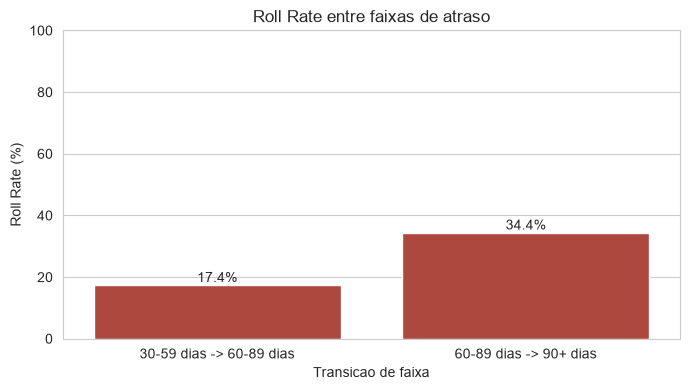

In [4]:
plt.figure(figsize=(7, 4))
labels = roll_rate_df["de"] + " -> " + roll_rate_df["para"]
sns.barplot(x=labels, y=roll_rate_df["roll_rate"] * 100, color="#c0392b")
plt.ylabel("Roll Rate (%)")
plt.xlabel("Transicao de faixa")
plt.title("Roll Rate entre faixas de atraso")
for i, v in enumerate(roll_rate_df["roll_rate"] * 100):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Interpretacao esperada**: o Roll Rate de "60-89 -> 90+" costuma ser mais
alto que o de "30-59 -> 60-89" - uma vez que o cliente ja acumulou atrasos
mais graves no historico, a chance de ele tambem ter chegado ao pior
estagio tende a aumentar. Confirme se e isso que aparece no grafico acima,
e pense: isso faz sentido com a ideia de que o risco se acumula, nao e
constante ao longo do tempo?

## Aging de Carteira

Distribuicao de toda a carteira pela pior faixa de atraso ja atingida por
cada cliente.

In [5]:
aging_df = calculate_aging(df)
aging_df

,faixa_aging,quantidade_clientes,percentual
0,Nunca atrasou,119906,79.94
1,30-59 dias,17213,11.48
2,60-89 dias,4811,3.21
3,90+ dias,8069,5.38


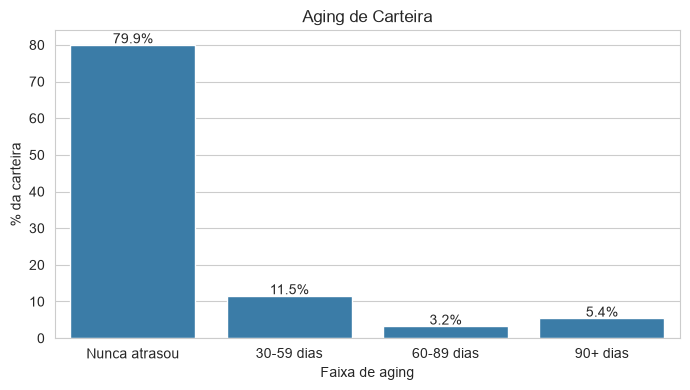

In [6]:
plt.figure(figsize=(7, 4))
sns.barplot(
    x=aging_df["faixa_aging"].astype(str),
    y=aging_df["percentual"],
    color="#2980b9",
)
plt.ylabel("% da carteira")
plt.xlabel("Faixa de aging")
plt.title("Aging de Carteira")
for i, v in enumerate(aging_df["percentual"]):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

**Interpretacao esperada**: a maior parte da carteira deve estar
concentrada em "Nunca atrasou" (a maioria dos clientes de credito, mesmo em
uma base de risco, nunca chega a atrasar) - o que e coerente com o
desbalanceamento de classes que ja vimos na modelagem (poucos inadimplentes
no total).

## Taxa de Cura

Entre os clientes que ja tiveram algum atraso no historico, qual percentual
NAO se tornou inadimplente grave nos 2 anos seguintes?

In [7]:
taxa_cura = calculate_cure_rate(df)
print(f"Taxa de Cura: {taxa_cura:.2%}")

Taxa de Cura: 78.02%


**Interpretacao esperada**: uma Taxa de Cura alta (por exemplo, acima de
50%) reforca um ponto pratico importante para o negocio - nem todo cliente
que atrasa vira uma perda, entao acionar cobranca agressiva para todo
mundo que atrasa pode ser desperdicio de esforco e ate prejudicar o
relacionamento com clientes que regularizariam sozinhos.

## Exportar para o Power BI

Salvamos os tres indicadores em `data/processed/` para que o dashboard do
Power BI (proxima etapa do projeto) possa consumir diretamente, sem
precisar rodar Python.

In [8]:
roll_rate_df.to_csv("../data/processed/roll_rate.csv", index=False)
aging_df.to_csv("../data/processed/aging_carteira.csv", index=False)

pd.DataFrame([{"taxa_cura": taxa_cura}]).to_csv(
    "../data/processed/taxa_cura.csv", index=False
)

print("Indicadores exportados para data/processed/.")

Indicadores exportados para data/processed/.


## Conclusoes

- Roll Rate: preencher apos rodar o notebook, com os valores obtidos.
- Aging de Carteira: preencher apos rodar o notebook.
- Taxa de Cura: preencher apos rodar o notebook.

**Proximos passos do projeto**: construir o dashboard em Power BI a partir
dos arquivos exportados acima, e (opcionalmente) implementar a camada de
IA generativa em `src/genai_explainer.py` para traduzir esses indicadores
em um resumo executivo em linguagem natural.